#### 분류 모델을 적용해서 분류하고 성능평가 하기
##### kn, svm, tree

In [1]:
import pandas as pd
import numpy as np

# Breast Cancer 데이터셋 가져오기 (출처: UCI ML Repository)
uci_path = 'https://archive.ics.uci.edu/ml/machine-learning-databases/\
breast-cancer-wisconsin/breast-cancer-wisconsin.data'
df = pd.read_csv(uci_path, header=None)

# 열 이름 지정
df.columns = ['id', 'clump', 'cell_size', 'cell_shape', 'adhesion', 'epithlial',
              'bare_nuclei', 'chromatin', 'normal_nucleoli', 'mitoses', 'target']

# 넘파이 라이브러리를 불러서 데이터 프레임의 target(class)의 값 종류 파악
# class라고 하니 못알아들어서 target으로 변경
np.unique(df.target)
# 2, 4로 구성되어있다는 것을 확인

array([2, 4])

In [2]:
# 타겟 2, 4를 0, 1로 변경
# map 혹은 apply 사용하여 변경가능
df['target'] = df['target'].map({2: 0, 4: 1})

In [3]:
df.head()

,id,clump,cell_size,cell_shape,adhesion,epithlial,bare_nuclei,chromatin,normal_nucleoli,mitoses,target
0,1000025,5,1,1,1,2,1,3,1,1,0
1,1002945,5,4,4,5,7,10,3,2,1,0
2,1015425,3,1,1,1,2,2,3,1,1,0
3,1016277,6,8,8,1,3,4,3,7,1,0
4,1017023,4,1,1,3,2,1,3,1,1,0


In [4]:
# df에 있는 숫자가 아닌 데이터 를 찾아서 na로 설정한다.
# na, 결측치를 어떻게 처리할까? - 여기선 삭제 하는걸로
df.info()

import pandas as pd
df.bare_nuclei = pd.to_numeric(df.bare_nuclei,errors='coerce')

df.isna().sum()

df = df.dropna()

df.info()

df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               699 non-null    int64 
 1   clump            699 non-null    int64 
 2   cell_size        699 non-null    int64 
 3   cell_shape       699 non-null    int64 
 4   adhesion         699 non-null    int64 
 5   epithlial        699 non-null    int64 
 6   bare_nuclei      699 non-null    object
 7   chromatin        699 non-null    int64 
 8   normal_nucleoli  699 non-null    int64 
 9   mitoses          699 non-null    int64 
 10  target           699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 683 entries, 0 to 698
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               683 non-null    int64  
 1   clump          

,id,clump,cell_size,cell_shape,adhesion,epithlial,bare_nuclei,chromatin,normal_nucleoli,mitoses,target
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0


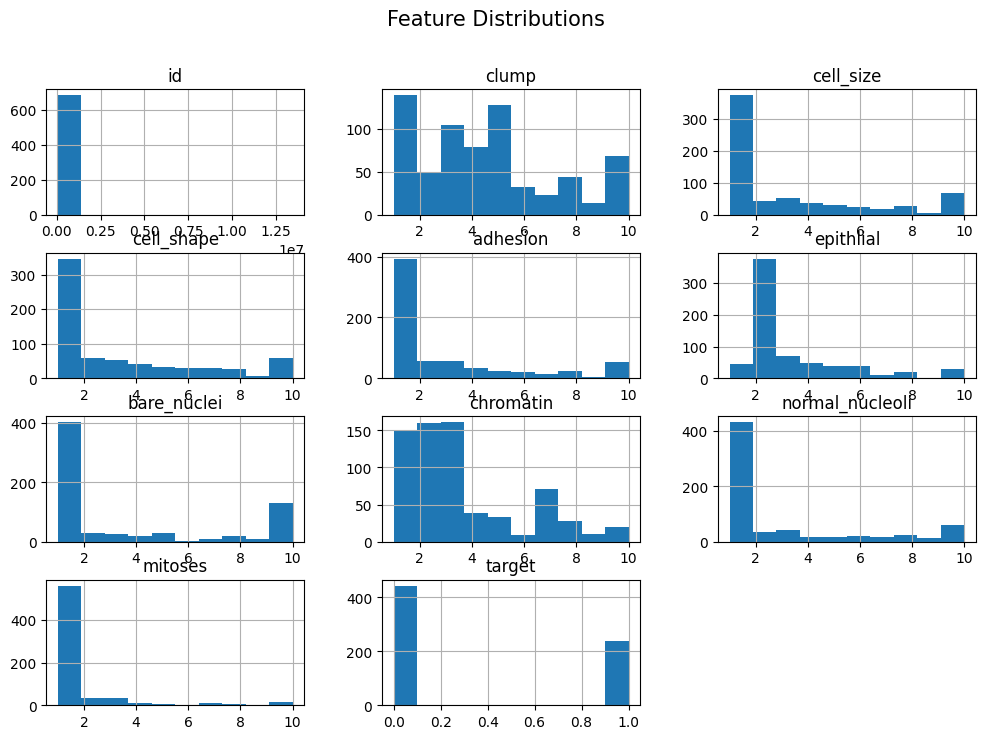

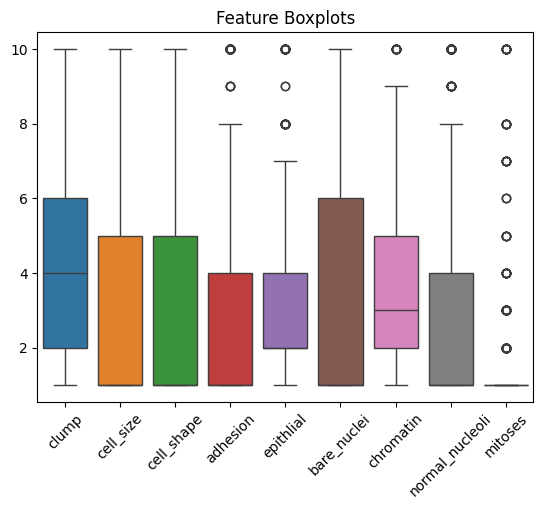

In [5]:
# 데이터 시각화
# 전체적인 데이터 모습 조회 : 히스토그램
import matplotlib.pyplot as plt
df.hist(figsize=(12,8), bins=10)
plt.suptitle("Feature Distributions", fontsize=15)
plt.show()
# 이상치 확인 : 박스플롯
import seaborn as sns
sns.boxplot(data=df.drop(columns=['id','target']))
plt.xticks(rotation=45)
plt.title("Feature Boxplots")
plt.show()

In [6]:
# 데이터 분리
# 7:3
from sklearn.model_selection import train_test_split

X = df.drop(columns=['id','target']).to_numpy() # 필요없는 열은 drop하기 및 넘파이 객체로 바꾸면서 수치만 있는 순수한 데이터로 변환
# y = df['target']
y = df.target

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3,stratify=y,random_state=42)

In [7]:
# 모델선택
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=3) # max_depth ^
# 학습
tree.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
# 평가
from sklearn.metrics import classification_report
# 학습한 데이터를 평가
# 학습하지 않은 데이터를 평가
# 두 수치가 차이가 많이 나면 과적합  (학습>평가)  overfitting  과대적합     
# 두 수치가 차이가 많이 나면 과적합  (학습<평가)  underfitting  과소적합        0.05 이상이면 보통 과적합

y_pred = tree.predict(x_train)
print( classification_report(y_train, y_pred) )

y_pred = tree.predict(x_test)
print( classification_report(y_test, y_pred) )

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       311
           1       0.96      0.94      0.95       167

    accuracy                           0.97       478
   macro avg       0.97      0.96      0.96       478
weighted avg       0.97      0.97      0.97       478

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       133
           1       0.93      0.93      0.93        72

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95       205



In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

knn = KNeighborsClassifier()
svm = SVC()

knn.fit(x_train, y_train)
svm.fit(x_train, y_train)

y_pred = knn.predict(x_test)
print('knn f1-score')
print(classification_report(y_test,y_pred))

print('svm f1-score')
y_pred = svm.predict(x_test)
print(classification_report(y_test,y_pred))

knn f1-score
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       133
           1       0.93      0.93      0.93        72

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95       205

svm f1-score
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       133
           1       0.93      0.97      0.95        72

    accuracy                           0.97       205
   macro avg       0.96      0.97      0.96       205
weighted avg       0.97      0.97      0.97       205



In [10]:
# 평가
from sklearn.metrics import classification_report
# 학습한 데이터를 평가
# 학습하지 않은 데이터를 평가
# 두 수치가 차이가 많이 나면 과적합  (학습>평가)  overfitting  과대적합     
# 두 수치가 차이가 많이 나면 과적합  (학습<평가)  underfitting  과소적합        0.05 이상이면 보통 과적합

y_pred = tree.predict(x_train)
print( classification_report(y_train, y_pred) )

y_pred = tree.predict(x_test)
print( classification_report(y_test, y_pred) )

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       311
           1       0.96      0.94      0.95       167

    accuracy                           0.97       478
   macro avg       0.97      0.96      0.96       478
weighted avg       0.97      0.97      0.97       478

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       133
           1       0.93      0.93      0.93        72

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95       205



In [ ]:
# 4️⃣ tree 모델에서의 과적합 완화 방법 (정상화 방법)
# 방법	설명
# ✅ 트리 가지치기 (Pruning)	트리의 깊이 제한을 둠. 예: DecisionTreeClassifier(max_depth=4)
# ✅ 최소 샘플 수 제한	min_samples_split=10, min_samples_leaf=5 등을 지정해 너무 세밀한 분할 방지
# ✅ 특징(Feature) 선택	의미 없는 feature가 있다면 제거하여 단순화
# ✅ 데이터 증강 / 수집	데이터가 부족할 경우, 더 많은 데이터로 일반화 향상
# ✅ 앙상블(Ensemble) 기법	랜덤포레스트나 그라디언트부스팅 같은 모델로 일반화 강화 (RandomForestClassifier 추천)
# ✅ 교차검증(Cross Validation)	모델이 특정 분할에만 과적합되는지 확인 가능

# 과적합 상태 여부 진단방법 알아보기 ^
# train 성능 수치 – test 성능 수치 의 차이가 0.05 이상일때,
# 같은 위치에 있는 성능 수치들을 비교하여 그차잇값이 0.05 이상일때,
# 과적합으로 판단한다.

# 전반적인 classification_report의 값을 보고 진단하는 법 물어보기 ^
# 0,1 중에서 1값이 중요한 모델일때 수치상으로는 f1-score 0.97 이지만, 실질적인 모델의 성능은 0.95
# 0,1 사이에 정확도 수치가 다른이유는 데이터 불균형하기때문이고, 이점을 보완하기위해서 오버 샘플링 혹은 언더 샘플링으로 데이터 갯수를 맞춘다.
# 1.00이 나올수가 없다는 점
# 모델별 과적합 완화방법 정리해보기 ^

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

knn = KNeighborsClassifier()
svm = SVC()

knn.fit(x_train, y_train)
svm.fit(x_train, y_train)

y_pred = knn.predict(x_test)
print('knn f1-score')
print(classification_report(y_test,y_pred))

print('svm f1-score')
y_pred = svm.predict(x_test)
print(classification_report(y_test,y_pred))

knn f1-score
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       133
           1       0.93      0.93      0.93        72

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95       205

svm f1-score
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       133
           1       0.93      0.97      0.95        72

    accuracy                           0.97       205
   macro avg       0.96      0.97      0.96       205
weighted avg       0.97      0.97      0.97       205

